# Landslide Risk Prediction Using Neural Network
This notebook demonstrates a full neural network workflow for landslide risk classification using the project dataset.

The neural network class below is copied directly from the models folder implementation (no module import from that file).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

%matplotlib inline

### Data Collection and Exploratory Inspection

In [2]:
landslide_data = pd.read_csv('../data/raw/landslide_dataset.csv', header=0)

In [3]:
landslide_data.head()

,Rainfall_mm,Slope_Angle,Soil_Saturation,Vegetation_Cover,Earthquake_Activity,Proximity_to_Water,Landslide,Soil_Type_Gravel,Soil_Type_Sand,Soil_Type_Silt
0,206.181018,58.275001,0.892798,0.339463,4.390047,0.099975,1,0,0,0
1,218.887334,36.679801,0.657147,0.360355,4.141029,0.832443,1,0,0,1
2,181.850867,31.363874,0.673362,0.221697,5.311891,0.023062,1,0,0,1
3,228.716199,38.995134,0.618666,0.489502,4.581928,0.785176,1,0,0,1
4,179.951067,42.998205,0.836966,0.118580,5.518862,0.450499,1,0,0,0


In [4]:
landslide_data.shape

(2000, 10)

In [5]:
landslide_data.describe()

,Rainfall_mm,Slope_Angle,Soil_Saturation,Vegetation_Cover,Earthquake_Activity,Proximity_to_Water,Landslide,Soil_Type_Gravel,Soil_Type_Sand,Soil_Type_Silt
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.0000,2000.00000
mean,176.688462,29.985404,0.540316,0.522862,3.604771,1.001867,0.500000,0.25850,0.2415,0.26100
std,65.724685,15.175902,0.295665,0.260426,1.895955,0.579964,0.500125,0.43792,0.4281,0.43929
min,50.036151,5.003944,0.000652,0.100005,0.001641,0.000653,0.000000,0.00000,0.0000,0.00000
25%,128.379762,18.018061,0.265634,0.295475,1.973415,0.500808,0.000000,0.00000,0.0000,0.00000
50%,177.013772,27.772833,0.599887,0.500191,3.996429,0.999761,0.500000,0.00000,0.0000,0.00000
75%,228.742286,41.683190,0.801994,0.740690,5.233897,1.505294,1.000000,1.00000,0.0000,1.00000
max,299.919102,59.966732,0.998831,0.999837,6.498670,1.999636,1.000000,1.00000,1.0000,1.00000


In [6]:
landslide_data['Landslide'].value_counts()

Landslide
1    1000
0    1000
Name: count, dtype: int64

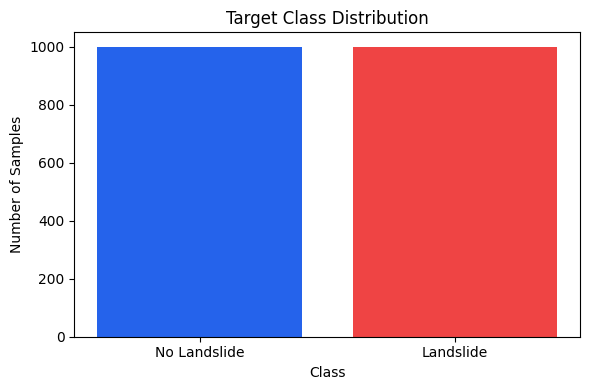

In [7]:
class_counts = landslide_data['Landslide'].value_counts().sort_index()
class_labels = ['No Landslide', 'Landslide']

plt.figure(figsize=(6, 4))
plt.bar(class_labels, class_counts.values, color=['#2563eb', '#ef4444'])
plt.title('Target Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.tight_layout()
plt.show()

1 -> Landslide  
0 -> No landslide

In [8]:
landslide_data.groupby('Landslide').mean()

,Rainfall_mm,Slope_Angle,Soil_Saturation,Vegetation_Cover,Earthquake_Activity,Proximity_to_Water,Soil_Type_Gravel,Soil_Type_Sand,Soil_Type_Silt
Landslide,,,,,,,,,
0,127.111331,17.717390,0.282473,0.748140,1.974215,1.502907,0.517,0.483,0.000
1,226.265592,42.253418,0.798160,0.297583,5.235326,0.500827,0.000,0.000,0.522


### Feature and Target Preparation

In [9]:
X = landslide_data.drop(columns=['Landslide'])
Y = landslide_data['Landslide']

In [18]:
print(X)

      Rainfall_mm  Slope_Angle  Soil_Saturation  Vegetation_Cover  \
0      206.181018    58.275001         0.892798          0.339463   
1      218.887334    36.679801         0.657147          0.360355   
2      181.850867    31.363874         0.673362          0.221697   
3      228.716199    38.995134         0.618666          0.489502   
4      179.951067    42.998205         0.836966          0.118580   
...           ...          ...              ...               ...   
1995   195.650778    27.084662         0.567332          0.556801   
1996   197.339684    22.715510         0.037470          0.517580   
1997    75.759674     6.631750         0.266207          0.925309   
1998    50.919297    16.603380         0.014794          0.954346   
1999   188.083126    28.372795         0.093188          0.516938   

      Earthquake_Activity  Proximity_to_Water  Soil_Type_Gravel  \
0                4.390047            0.099975                 0   
1                4.141029            

In [19]:
print(Y)

0       1
1       1
2       1
3       1
4       1
       ..
1995    0
1996    0
1997    0
1998    0
1999    0
Name: Landslide, Length: 2000, dtype: int64


### Splitting Data Into Training and Testing Sets

In [10]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, stratify=Y, random_state=2
)

print(X.shape, X_train.shape, X_test.shape)

(2000, 9) (1600, 9) (400, 9)


### Feature Scaling

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Neural Network Class (Copied From Models Folder)

In [12]:
class NeuralNetwork:
    """
    Simple feedforward NN: Input(9) -> Dense(62, ReLU) -> Dense(32, ReLU) -> Dense(1, Sigmoid)
    Trained with mini - batch SGD + binary cross-entropy loss.
    """

    def __init__(self, lr=0.001, epoches=200, batch_size=32):
        self.lr = lr
        self.epochs = epoches
        self.batch_size = batch_size
        self.losses = []

    @staticmethod
    def _relu(z):
        return np.maximum(0, z)
    
    @staticmethod
    def _relu_d(z):
        return (z > 0).astype(float)
    
    @staticmethod
    def _sigmoid(z):
        return 1 / ( 1 + np.exp(-np.clip(z, -500, 500)))
    
    def _init_weights(self, n_in):
        np.random.seed(42)
        self.W1 = np.random.randn(n_in, 64) * np.sqrt(2 / n_in)
        self.b1 = np.zeros((1, 64))
        self.W2 = np.random.randn(64, 32) * np.sqrt(2 / 64)
        self.b2 = np.zeros((1, 32))
        self.W3 = np.random.randn(32, 1) * np.sqrt(2 / 32)
        self.b3 = np.zeros((1, 1))

    def _forward(self, X):
        self.Z1 = X @ self.W1 + self.b1
        self.A1 = self._relu(self.Z1)

        self.Z2 = self.A1 @ self.W2 + self.b2
        self.A2 = self._relu(self.Z2)

        self.Z3 = self.A2 @ self.W3 + self.b3
        self.A3 = self._sigmoid(self.Z3)
        return self.A3
    
    def _backward(self, X, y):
        m = X.shape[0]
        y = y.reshape(-1, 1)

        dZ3 = self.A3 - y
        dW3 = self.A2.T @ dZ3 / m
        db3 = dZ3.mean(axis=0, keepdims=True)

        dA2 = dZ3 @ self.W3.T
        dZ2 = dA2 * self._relu_d(self.Z2)
        dW2 = self.A1.T @ dZ2 / m
        db2 = dZ2.mean(axis=0, keepdims=True)

        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * self._relu_d(self.Z1)
        dW1 = X.T @ dZ1 / m
        db1 = dZ1.mean(axis=0, keepdims=True)

        self.W3 -= self.lr * dW3
        self.b3 -= self.lr * db3
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def fit(self, X, y):
        self._init_weights(X.shape[1])

        for epoch in range(self.epochs):
            idx = np.random.permutation(len(X))
            X_s, y_z = X[idx], y[idx]
            epoch_loss = 0

            for i in range(0, len(X_s), self.batch_size):
                Xb = X_s[i:i + self.batch_size]
                yb = y_z[i:i + self.batch_size]

                out = self._forward(Xb)
                self._backward(Xb, yb)

                eps = 1e-9
                epoch_loss += -np.mean(
                    yb * np.log(out + eps) + (1 - yb) * np.log(1 - out + eps)
                )

            self.losses.append(epoch_loss)

            if (epoch + 1) % 50 == 0:
                preds = self.predict(X)
                acc = accuracy_score(y, preds)
                print(
                    f"      Epoch {epoch+1:>3}/{self.epochs}  "
                    f"loss={epoch_loss:.4f}  train_acc={acc:.4f}"
                )


    def predict_proba(self, X):
        return self._forward(X).flatten()
    
    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

### Building and Training the Neural Network Model

In [13]:
nn_model = NeuralNetwork(lr=0.001, epoches=200, batch_size=32)
nn_model.fit(X_train_scaled, Y_train.values)

      Epoch  50/200  loss=101.5618  train_acc=1.0000
      Epoch 100/200  loss=126.1901  train_acc=1.0000
      Epoch 150/200  loss=140.0716  train_acc=1.0000
      Epoch 200/200  loss=150.1178  train_acc=1.0000


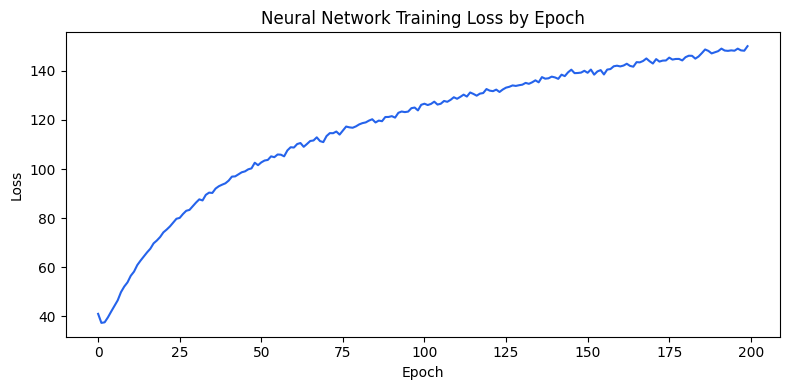

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(nn_model.losses, color='#2563eb')
plt.title('Neural Network Training Loss by Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.tight_layout()
plt.show()

### Model Evaluation Using Accuracy Score

In [15]:
X_train_prediction = nn_model.predict(X_train_scaled)
training_data_accuracy = accuracy_score(Y_train, X_train_prediction)

print('Accuracy score of the training data : ', training_data_accuracy)

Accuracy score of the training data :  1.0


In [16]:
X_test_prediction = nn_model.predict(X_test_scaled)
test_data_accuracy = accuracy_score(Y_test, X_test_prediction)

print('Accuracy score of the test data : ', test_data_accuracy)

Accuracy score of the test data :  1.0


### Making a Predictive System

In [17]:
input_data = pd.DataFrame([
    {
        'Rainfall_mm': 210.0,
        'Slope_Angle': 35.0,
        'Soil_Saturation': 0.82,
        'Vegetation_Cover': 0.25,
        'Earthquake_Activity': 4.8,
        'Proximity_to_Water': 0.45,
        'Soil_Type_Gravel': 0,
        'Soil_Type_Sand': 1,
        'Soil_Type_Silt': 0,
    }
])

input_data = input_data[X.columns]
input_data_scaled = scaler.transform(input_data)
prediction = nn_model.predict(input_data_scaled)

print('Predicted Class:', prediction[0])
if prediction[0] == 1:
    print('The area is at risk of a landslide.')
else:
    print('The area is not at risk of a landslide.')

Predicted Class: 1
The area is at risk of a landslide.
